## MNIST

In [1]:
from sklearn.datasets import fetch_openml

In [2]:
mnist = fetch_openml('mnist_784', as_frame=False)

In [3]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [4]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [5]:
# mnist is a bunch datatype
#type(mnist)

In [6]:
# X is the data columns, y is the target column
X, y = mnist['data'], mnist['target']

In [7]:
# show the first 5 rows
X[:5]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [8]:
# 70000 rows, 784 columns
X.shape

(70000, 784)

In [9]:
# show first 5 rows of the array
y[:5]

array(['5', '0', '4', '1', '9'], dtype=object)

In [10]:
# 70000 rows, 1 column
y.shape

(70000,)

#### Plot one of the images

In [11]:
import matplotlib.pyplot as plt


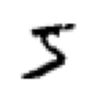

In [12]:
def plot_digit(image_data):
  image = image_data.reshape(28,28)
  plt.figure(figsize=(1,1)) # make a 1 x 1 image to better visualize number
  plt.imshow(image, cmap='binary')
  plt.axis('off')
some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [13]:
y[0]

'5'

#### Plot more number images

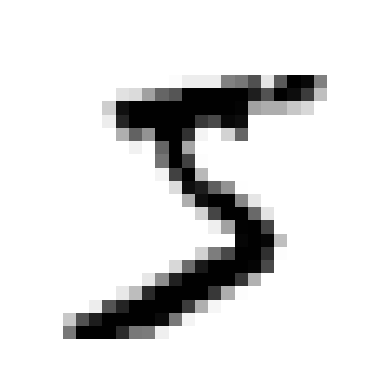

In [14]:
def plot_digit(image_data):
  image = image_data.reshape(28,28)
  plt.imshow(image, cmap='binary')
  plt.axis('off')
some_digit = X[0]
plot_digit(some_digit)
plt.show()

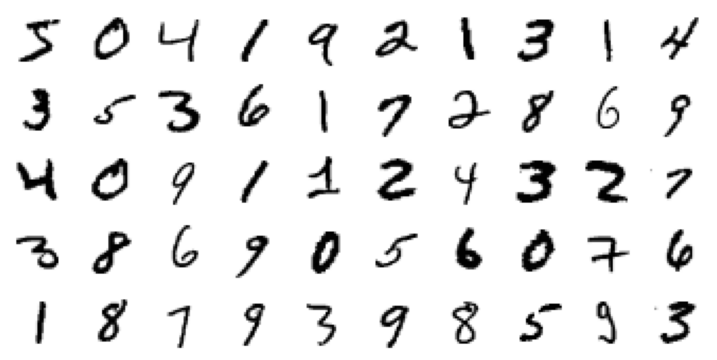

In [15]:
plt.figure(figsize=(9,9))
for idx, image_data in enumerate(X[:50]):
  image = image_data.reshape(28,28)
  plt.subplot(10,10,idx+1)
  plot_digit(image_data) # plot using function above
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.show()

### Training a Binary Classifier

In [16]:
X_train, X_test, y_train, y_test = (X[:60000],
                                   X[60000:],
                                   y[:60000],
                                   y[60000:])

In [17]:
y_train_5 = (y_train == '5') # Set to True is a 5, else set to False

In [18]:
y_train_5[:5] # The first row is a five, the other rows are not 5

array([ True, False, False, False, False])

In [19]:
from sklearn.linear_model import SGDClassifier

In [20]:
sgd_clf = SGDClassifier(random_state=42).fit(X_train, y_train_5)

In [21]:
sgd_clf.predict([some_digit])

array([ True])

### Performance Measures

### Measuring Accuracy Using Cross Validation

In [22]:
from sklearn.model_selection import cross_val_score

In [23]:
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

In [25]:
skfolds = StratifiedKFold(n_splits=3)

for train_index, test_index in skfolds.split(X_train, y_train_5):
  clone_clf = clone(sgd_clf)
  X_train_folds = X_train[train_index] # this is the training attributes/features
  y_train_folds = y_train_5[train_index]
  X_test_folds = X_train[test_index] # this is the training labels/target
  y_test_folds = y_train_5[test_index] # this is the training labels/target

  # fit the sgd classifier using the X and y training kfolds
  clone_clf.fit(X_train_folds, y_train_folds)

  # using the shd classifier clone model, predict values using the X test data
  y_pred = clone_clf.predict(X_test_folds)

  # compare the predicted y value to the test/actual y values
  # and get the total number that matched
  n_correct = sum(y_pred == y_test_folds)
  print(n_correct / len(y_pred)) # print the 3 Kfold accuracy percentage

0.95035
0.96035
0.9604


### Build Dummy Classifier to get Miminum Accuracy

In [26]:
from sklearn.dummy import DummyClassifier

In [27]:
dummy_clf = DummyClassifier().fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [28]:
# get the accuracy score of the dummy classifier
# the dummy value used to check is the most frequent class (False) value
# Then it checks to see how many rows have the "False" value
# below accuracy means about 10% of rows have a 5
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

### Confusion Matrix

In [29]:
from sklearn.model_selection import cross_val_predict

In [30]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [31]:
from sklearn.metrics import confusion_matrix

In [32]:
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [33]:
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

### Precision and Recall

In [34]:
from sklearn.metrics import precision_score, recall_score

In [35]:
precision_score(y_train_5, y_train_pred) #3530 / (3530+687)

0.8370879772350012

In [36]:
# calculate precision_score using the confusion_matrix (cm) numpy array
cm[1,1] / (cm[1,1] + cm[0,1])

np.float64(0.8370879772350012)

In [37]:
recall_score(y_train_5, y_train_pred) # 3530 / (3530_1891)

0.6511713705958311

In [38]:
# calculate recall_score using the confusion_matrix (cm) numpy array
cm[1,1] / (cm[1,1]+cm[1,0])

np.float64(0.6511713705958311)

### F1 score

In [39]:
from sklearn.metrics import f1_score

In [40]:
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [41]:
# calculate f1_score using the confusion_matrix (cm) numpy array
cm[1,1] / (cm[1,1] + ((cm[1,0] + cm[0,1]) / 2))

np.float64(0.7325171197343847)

### Precision / Recall Trade-Off

In [42]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [43]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [44]:
# same as above math-wize
y_scores > 0

array([ True])

In [45]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [46]:
# returns all the decision scores of the all rows in the training set
# decision score is what is used to predict the True/False of the target
y_scores = cross_val_predict(sgd_clf,
                             X_train,
                             y_train_5, # this is the target
                             cv=3,
                             method='decision_function')

In [47]:
y_scores[:5]

array([  1200.93051237, -26883.79202424, -33072.03475406, -15919.5480689 ,
       -20003.53970191])

#### Graph a precision_recall_curve

In [48]:
from sklearn.metrics import precision_recall_curve

In [49]:
# y_train_5 is the actual target values
# y_scores is the predict target decision scores
# get the precision and recall values for all possible and thresholds y_scores
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

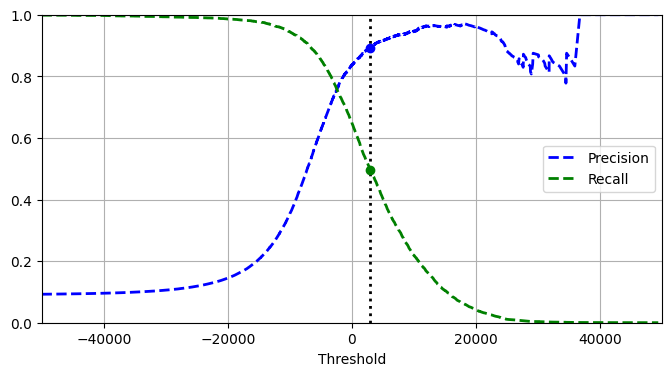

In [50]:
plt.figure(figsize=(8,4))
plt.plot(thresholds,
         precisions[:-1],
         'b--',
         label='Precision',
         linewidth=2)
plt.plot(thresholds,
         recalls[:-1],
         'g--',
         label='Recall',
         linewidth=2)
plt.vlines(threshold, 0, 1.0, 'k', 'dotted', linewidth=2)
idx = (thresholds >= threshold).argmax()

# add a blue dot to where threshold equals precision
plt.plot(thresholds[idx], precisions[idx],"bo")

# add a green dot to where threshold equals recall
plt.plot(thresholds[idx], recalls[idx],"go")
plt.axis([-50000, 50000, 0, 1]) # to shrink the axis size
plt.grid()
plt.xlabel('Threshold')
plt.legend(loc='center right')
plt.show()

### Graph an alternative precision/recall curve

In [51]:
import matplotlib.patches as patches

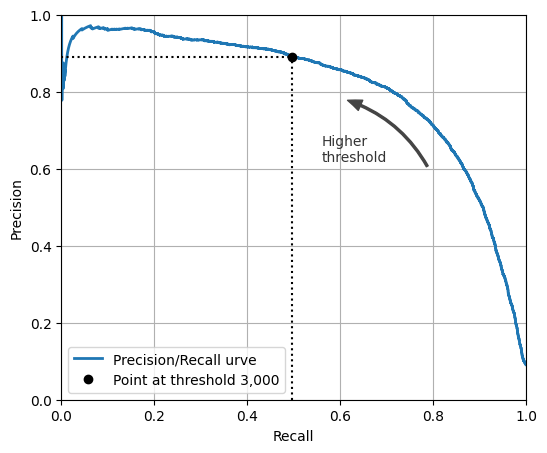

In [52]:

idx = (thresholds >= threshold).argmax()
threshold = 3000

# X axis is recall, y axis is precision
plt.figure(figsize=(6,5))
plt.plot(recalls,
         precisions,
         linewidth=2,
         label = 'Precision/Recall urve')

# plot the vertical line where the recall meets the threshold
plt.plot([recalls[idx], recalls[idx]], [0,precisions[idx]], 'k:')

# plot the horizontal line where the precision meets the threshold
plt.plot([0, recalls[idx]], [precisions[idx],precisions[idx]], 'k:')

# add dot to where the threshold meets the precision/recall line
plt.plot([recalls[idx]], [precisions[idx]], 'ko',
         label='Point at threshold 3,000')

# add a curved arrow to plot
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))

plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

In [53]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [54]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [55]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [56]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

### The ROC Curve

In [57]:
from sklearn.metrics import roc_curve

In [58]:
# y_train_5 is the actual target values
# y_scores is the predict target decision scores
# get the fpr and tpr values for all possible threshold y_scores
# FPR = False positive  (ratio of negative instances that are labeled positive)
# TPR = True positive rate (recall score)
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

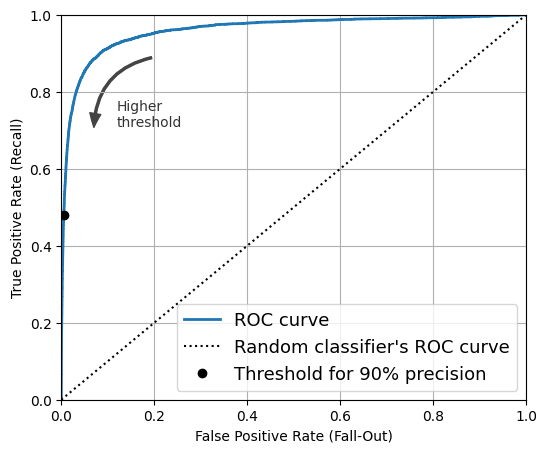

In [59]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label='ROC curve')
plt.plot([0,1],[0,1],'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90],[tpr_90], 'ko', label="Threshold for 90% precision")

# add curved arrow to plot
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))

plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
plt.grid()

In [60]:
from sklearn.metrics import roc_auc_score

In [61]:
roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

### Random Forest Classifier

In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
forest_clf = RandomForestClassifier(random_state=42)

In [64]:
y_probas_forest = cross_val_predict(forest_clf,
                                    X_train,
                                    y_train_5,
                                    cv=3,
                                    method='predict_proba')

In [65]:
y_probas_forest[:5]

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       [1.  , 0.  ],
       [0.99, 0.01]])

In [66]:
idx_50_to_60 = (y_probas_forest[:,1] > 0.5) & (y_probas_forest[:,1] < 0.6)
print(f"{(y_train_5[idx_50_to_60]).sum() / idx_50_to_60.sum():.1%}")

94.0%


In [67]:
y_scores_forest = y_probas_forest[:,1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

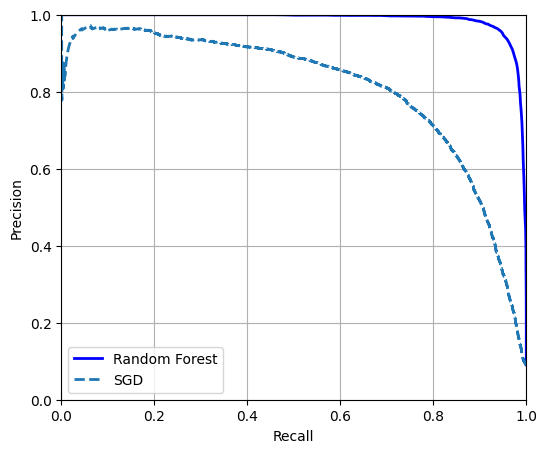

In [68]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# extra code – just beautifies and saves Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
plt.show()

In [69]:
y_train_pred_forest = y_probas_forest[:,1]>0.5
f1_score(y_train_5, y_train_pred_forest)

0.9242275142688448

In [70]:
# returns True for those rows where the probability score was >= 0.5
y_probas_forest[:,1] >=0.5

array([ True, False, False, ...,  True, False, False])

In [71]:
roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.9983436731328145)

In [72]:
precision_score(y_train_5, y_train_pred_forest)

0.9905083315756169

In [73]:
recall_score(y_train_5, y_train_pred_forest)

0.8662608374838591

### Multiclass Classification

In [74]:
from sklearn.svm import SVC

#### SVC Multiclass Classification

In [75]:
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000]) # y is the full set

SVC(random_state=42)

In [76]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [77]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [78]:
class_id = some_digit_scores.argmax()
class_id

np.int64(5)

In [79]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [80]:
svm_clf.classes_[class_id]

'5'

#### Code to return all 45 scores using decision_function()

If you want `decision_function()` to return all 45 scores, you can set the `decision_function_shape` hyperparameter to `"ovo"`. The default value is `"ovr"`, but don't let this confuse you: `SVC` always uses OvO for training. This hyperparameter only affects whether or not the 45 scores get aggregated or not:

In [81]:
svm_clf.decision_function_shape='ovo'
some_digit_scores_ovo = svm_clf.decision_function([some_digit])
some_digit_scores_ovo.round(2)

array([[ 0.11, -0.21, -0.97,  0.51, -1.01,  0.19,  0.09, -0.31, -0.04,
        -0.45, -1.28,  0.25, -1.01, -0.13, -0.32, -0.9 , -0.36, -0.93,
         0.79, -1.  ,  0.45,  0.24, -0.24,  0.25,  1.54, -0.77,  1.11,
         1.13,  1.04,  1.2 , -1.42, -0.53, -0.45, -0.99, -0.95,  1.21,
         1.  ,  1.  ,  1.08, -0.02, -0.67, -0.14, -0.3 , -0.13,  0.25]])

#### OneVsRestClassifier

This uses 10 scores and the class with the highest score is the output

In [82]:
from sklearn.multiclass import OneVsRestClassifier

In [84]:
ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [85]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [86]:
len(ovr_clf.estimators_)

10

In [87]:
# the 6th score is the one it will use. This corresponds to the '5'
ovr_clf.decision_function([some_digit])

array([[-1.32802451, -1.79073853, -1.39262214, -0.94416346, -2.29003973,
         0.80921042, -1.72304481, -1.20954271, -1.63739176, -1.79246052]])

#### SGD Multiclass Classifier

In [88]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [89]:
sgd_clf.decision_function([some_digit])

array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [90]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring='accuracy')

array([0.87365, 0.85835, 0.8689 ])

#### Use SGD Multiclass Classifier with the Stand Scaler

In [91]:
from sklearn.preprocessing import StandardScaler

In [92]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype('float64'))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring='accuracy')


array([0.8983, 0.891 , 0.9018])

### Error Analysis

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay

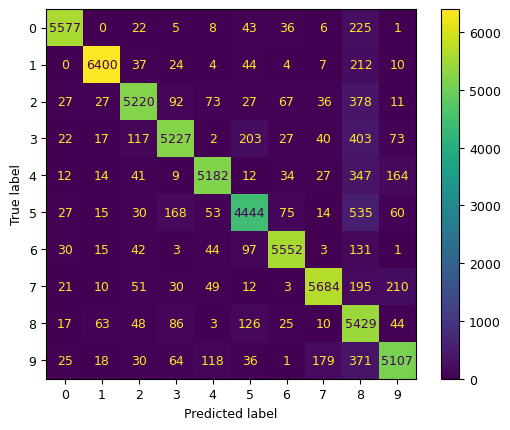

In [95]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
plt.rc('font', size=9) # To make the test smaller
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.grid(False)
plt.show()

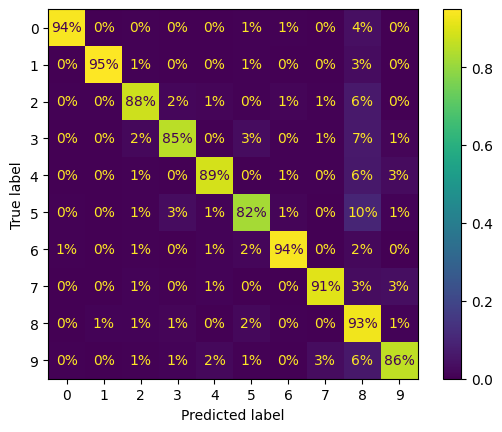

In [96]:
plt.rc('font',size=10)
ConfusionMatrixDisplay.from_predictions(y_train,
                                        y_train_pred,
                                        normalize='true',
                                        values_format='0.0%')
plt.show()

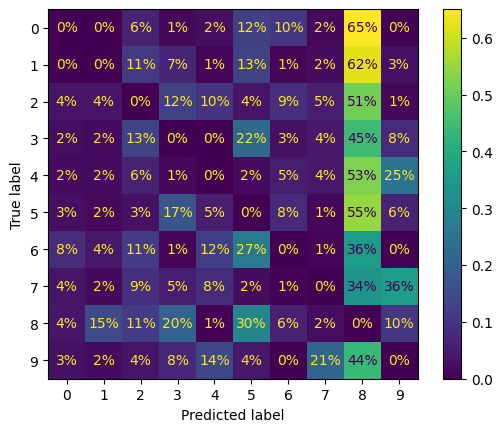

In [97]:
sample_weight = (y_train_pred != y_train)
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train,
                                        y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize='true',
                                        values_format='0.0%')
plt.show()

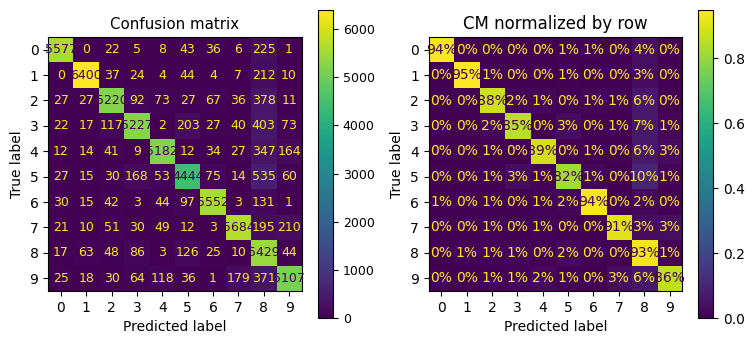

In [98]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0])
axs[0].set_title("Confusion matrix")
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        normalize="true", values_format=".0%")
axs[1].set_title("CM normalized by row")
plt.show()

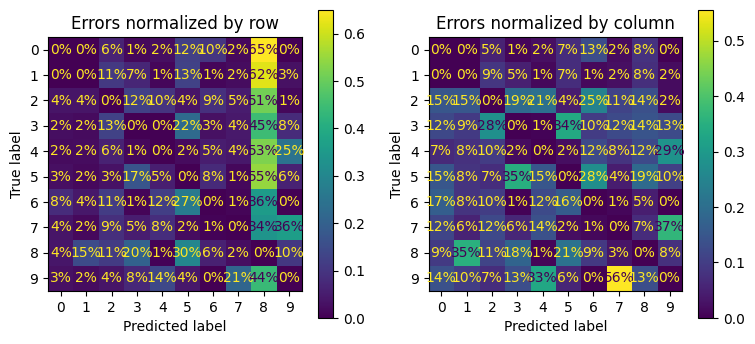

In [99]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0],
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
axs[0].set_title("Errors normalized by row")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
axs[1].set_title("Errors normalized by column")
plt.show()
plt.rc('font', size=14)  # make fonts great again

#### Analyze the #s and 5s

In [101]:
cl_a, cl_b = '3','5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

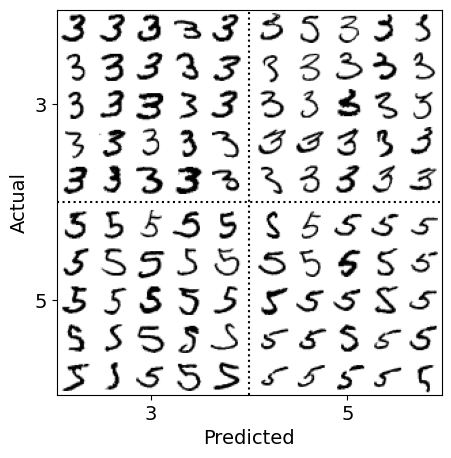

In [102]:
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0,0)),
                                       (X_bb, (1,0)),
                                       (X_aa, (0,1)),
                                       (X_ab, (1,1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28,28), cmap='binary',
                   extent=(x, x+1, y, y+1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2*size + pad], "k:")
plt.plot([0, 2*size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2*size + pad, 0, 2*size + pad])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### Multilabel Classification

In [103]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

In [104]:
y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') %2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

In [106]:
y_multilabel

array([[False,  True],
       [False, False],
       [False, False],
       ...,
       [False,  True],
       [False, False],
       [ True, False]])

In [107]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [108]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [109]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average='macro')

0.9764102655606048

In [110]:
f1_score(y_multilabel, y_train_knn_pred, average='weighted')

0.9778357403921755

### Classifier Chain

In [111]:
from sklearn.multioutput import ClassifierChain

In [113]:
chain_clf = ClassifierChain(SVC(),
                            cv=3,
                            random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

ClassifierChain(base_estimator=SVC(), cv=3, random_state=42)

In [114]:
chain_clf.predict([some_digit])

array([[0., 1.]])

### Multioutput Classification

In [115]:
np.random.seed(42)
noise = np.random.randint(0,100, (len(X_train),784))
X_train_mod = X_train + noise
noise = np.random.randint(0,100, (len(X_test),784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

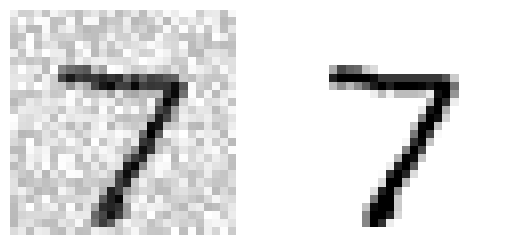

In [116]:
plt.subplot(121); plot_digit(X_test_mod[0])
plt.subplot(122); plot_digit(y_test_mod[0])
plt.show()

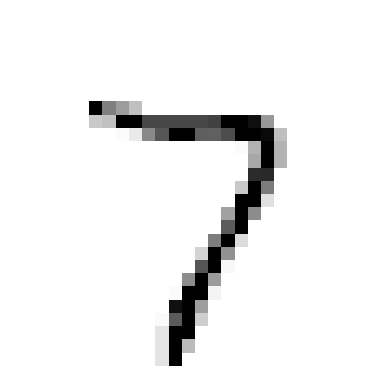

In [117]:
knn_clf = KNeighborsClassifier().fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()